# Лабораторная работа №3
  
## Тема: Частотный анализ
  
## Цель работы: Ознакомиться с методами частотного анализа из библиотеки MLxtend.

**Студент:** Магомедов Имран Борисович  
**Группа:** ПИЖ-Б-О-22-1  
**Курс/Семестр:** 4/8  

## Методика и порядок выполнения работы

In [27]:
import warnings

warnings.filterwarnings("ignore")

In [28]:
!pip install mlxtend

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

### Загрузка данных

2. Загрузка данных в датафрейм

In [30]:
all_data = pd.read_csv('/content/drive/MyDrive/NCFU/ОиАБД/Отчеты/Лабораторная работа №3/data/dataset_group.csv', header=None)

3. Получение списка всех id покупателей

In [31]:
unique_id = list(set(all_data[1]))
print(f"Количество уникальных покупателей: {len(unique_id)}")

Количество уникальных покупателей: 1139


4. Получение списка всех товаров

In [32]:
items = list(set(all_data[2]))
print(f"Количество уникальных товаров: {len(items)}")

Количество уникальных товаров: 38


5. Формирование датасета для частотного анализа

In [33]:
dataset = [[elem for elem in all_data[all_data[1] == id][2] if elem in items] for id in unique_id]
print(f"Количество транзакций: {len(dataset)}")
print("Пример первых 3 транзакций:")
for i in range(min(3, len(dataset))):
    print(f"  {dataset[i]}")

Количество транзакций: 1139
Пример первых 3 транзакций:
  ['yogurt', 'pork', 'sandwich bags', 'lunch meat', 'all- purpose', 'flour', 'soda', 'butter', 'vegetables', 'beef', 'aluminum foil', 'all- purpose', 'dinner rolls', 'shampoo', 'all- purpose', 'mixes', 'soap', 'laundry detergent', 'ice cream', 'dinner rolls']
  ['toilet paper', 'shampoo', 'hand soap', 'waffles', 'vegetables', 'cheeses', 'mixes', 'milk', 'sandwich bags', 'laundry detergent', 'dishwashing liquid/detergent', 'waffles', 'individual meals', 'hand soap', 'vegetables', 'individual meals', 'yogurt', 'cereals', 'shampoo', 'vegetables', 'aluminum foil', 'tortillas', 'mixes']
  ['soda', 'pork', 'soap', 'ice cream', 'toilet paper', 'dinner rolls', 'hand soap', 'spaghetti sauce', 'milk', 'ketchup', 'sandwich loaves', 'poultry', 'toilet paper', 'ice cream', 'ketchup', 'vegetables', 'laundry detergent', 'spaghetti sauce', 'bagels', 'soap', 'ice cream', 'shampoo', 'lunch meat', 'cereals', 'spaghetti sauce', 'pork', 'vegetables', 

### Подготовка данных

1. Кодирование данных с помощью TransactionEncoder

In [34]:
te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

2. Вывод полученного датафрейма

In [35]:
print("\n=== Закодированный датафрейм ===")
print(f"Размер датафрейма: {df.shape}")
print("Первые 5 строк:")
print(df.head())
print("\nОбъяснение: данные представлены в виде бинарной матрицы, где строки - транзакции, столбцы - товары,")
print("1 означает, что товар присутствует в транзакции, 0 - отсутствует")


=== Закодированный датафрейм ===
Размер датафрейма: (1139, 38)
Первые 5 строк:
   all- purpose  aluminum foil  bagels   beef  butter  cereals  cheeses  \
0          True           True   False   True    True    False    False   
1         False           True   False  False   False     True     True   
2         False          False    True  False   False     True     True   
3          True          False   False  False   False     True    False   
4          True          False   False  False   False    False    False   

   coffee/tea  dinner rolls  dishwashing liquid/detergent  ...  shampoo  \
0       False          True                         False  ...     True   
1       False         False                          True  ...     True   
2       False          True                         False  ...     True   
3       False         False                         False  ...    False   
4       False          True                         False  ...    False   

    soap   soda  s

### Ассоциативный анализ с использованием Apriori

1. Apriori с min_support=0.3

In [36]:
print("\n=== Apriori (min_support=0.3) ===")
results = apriori(df, min_support=0.3, use_colnames=True)
results['length'] = results['itemsets'].apply(lambda x: len(x))
print(results)
print("\nОбъяснение: получены частые наборы товаров, встречающиеся не менее чем в 30% транзакций")


=== Apriori (min_support=0.3) ===
     support                                    itemsets  length
0   0.374890                              (all- purpose)       1
1   0.384548                             (aluminum foil)       1
2   0.385426                                    (bagels)       1
3   0.374890                                      (beef)       1
4   0.367867                                    (butter)       1
5   0.395961                                   (cereals)       1
6   0.390694                                   (cheeses)       1
7   0.379280                                (coffee/tea)       1
8   0.388938                              (dinner rolls)       1
9   0.388060              (dishwashing liquid/detergent)       1
10  0.389816                                      (eggs)       1
11  0.352941                                     (flour)       1
12  0.370500                                    (fruits)       1
13  0.345917                                 (hand soap

2. Apriori с max_len=1

In [37]:
print("\n=== Apriori (min_support=0.3, max_len=1) ===")
results_len1 = apriori(df, min_support=0.3, use_colnames=True, max_len=1)
print(results_len1)


=== Apriori (min_support=0.3, max_len=1) ===
     support                        itemsets
0   0.374890                  (all- purpose)
1   0.384548                 (aluminum foil)
2   0.385426                        (bagels)
3   0.374890                          (beef)
4   0.367867                        (butter)
5   0.395961                       (cereals)
6   0.390694                       (cheeses)
7   0.379280                    (coffee/tea)
8   0.388938                  (dinner rolls)
9   0.388060  (dishwashing liquid/detergent)
10  0.389816                          (eggs)
11  0.352941                         (flour)
12  0.370500                        (fruits)
13  0.345917                     (hand soap)
14  0.398595                     (ice cream)
15  0.375768              (individual meals)
16  0.376646                         (juice)
17  0.371378                       (ketchup)
18  0.378402             (laundry detergent)
19  0.395083                    (lunch meat)
20  0.380

3. Apriori с размером набора = 2

In [38]:
print("\n=== Apriori (наборы размера 2) ===")
results = apriori(df, min_support=0.3, use_colnames=True)
results['length'] = results['itemsets'].apply(lambda x: len(x))
results_size2 = results[results['length'] == 2]
print(results_size2)
print(f'\nКоличество наборов размера 2: {len(results_size2)}')


=== Apriori (наборы размера 2) ===
     support                                    itemsets  length
38  0.310799                 (aluminum foil, vegetables)       2
39  0.300263                        (bagels, vegetables)       2
40  0.310799                       (cereals, vegetables)       2
41  0.309043                       (cheeses, vegetables)       2
42  0.308165                  (dinner rolls, vegetables)       2
43  0.306409  (dishwashing liquid/detergent, vegetables)       2
44  0.326602                          (eggs, vegetables)       2
45  0.302897                     (ice cream, vegetables)       2
46  0.309043             (laundry detergent, vegetables)       2
47  0.311677                    (lunch meat, vegetables)       2
48  0.331870                       (vegetables, poultry)       2
49  0.305531                          (soda, vegetables)       2
50  0.315189                       (waffles, vegetables)       2
51  0.319579                        (yogurt, vegetable

4. Зависимость количества наборов от уровня поддержки


=== Зависимость количества наборов от поддержки ===


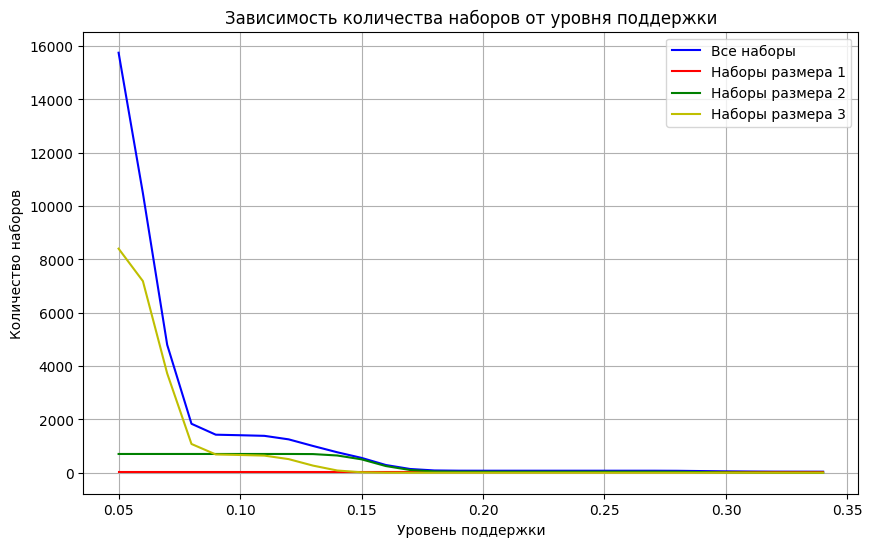

In [39]:
print("\n=== Зависимость количества наборов от поддержки ===")
support_levels = np.arange(0.05, 0.35, 0.01)
counts = []
counts_len1 = []
counts_len2 = []
counts_len3 = []

for support in support_levels:
    res = apriori(df, min_support=support, use_colnames=True)
    res['length'] = res['itemsets'].apply(lambda x: len(x))
    counts.append(len(res))
    counts_len1.append(len(res[res['length'] == 1]))
    counts_len2.append(len(res[res['length'] == 2]))
    counts_len3.append(len(res[res['length'] == 3]))

plt.figure(figsize=(10, 6))
plt.plot(support_levels, counts, 'b-', label='Все наборы')
plt.plot(support_levels, counts_len1, 'r-', label='Наборы размера 1')
plt.plot(support_levels, counts_len2, 'g-', label='Наборы размера 2')
plt.plot(support_levels, counts_len3, 'y-', label='Наборы размера 3')
plt.xlabel('Уровень поддержки')
plt.ylabel('Количество наборов')
plt.title('Зависимость количества наборов от уровня поддержки')
plt.legend()
plt.grid()
plt.show()

5. Определение порогов поддержки для наборов разного размера


=== Пороговые значения поддержки ===
Наборы размера 2 перестают генерироваться при поддержке > 0.34
Наборы размера 3 перестают генерироваться при поддержке > 0.17


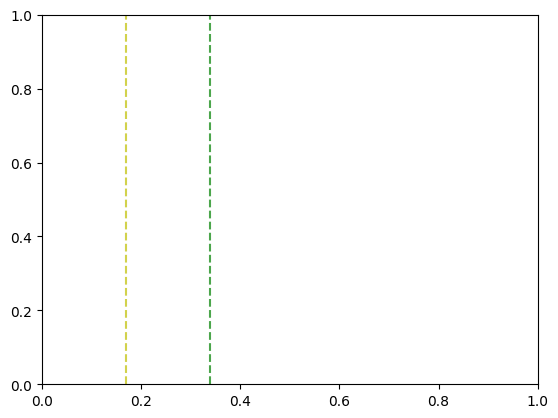

In [40]:
print("\n=== Пороговые значения поддержки ===")
for length in [1, 2, 3]:
    for support in support_levels:
        res = apriori(df, min_support=support, use_colnames=True)
        res['length'] = res['itemsets'].apply(lambda x: len(x))
        if len(res[res['length'] == length]) == 0:
            print(f"Наборы размера {length} перестают генерироваться при поддержке > {support:.2f}")
            plt.axvline(x=support, color=['r','g','y'][length-1], linestyle='--', alpha=0.7)
            break
plt.show()

6. Построение датасета из элементов, попадающих в наборы размера 1 при поддержке 0.38

In [41]:
print("\n=== Создание нового датасета (поддержка 0.38) ===")
results_38 = apriori(df, min_support=0.38, use_colnames=True, max_len=1)
new_items = [list(elem)[0] for elem in results_38['itemsets']]
print(f"Отобранные товары: {new_items}")

new_dataset = [[elem for elem in all_data[all_data[1] == id][2] if elem in new_items] for id in unique_id]
print(f"Размер нового датасета: {len(new_dataset)} транзакций")


=== Создание нового датасета (поддержка 0.38) ===
Отобранные товары: ['aluminum foil', 'bagels', 'cereals', 'cheeses', 'dinner rolls', 'dishwashing liquid/detergent', 'eggs', 'ice cream', 'lunch meat', 'milk', 'poultry', 'soda', 'vegetables', 'waffles', 'yogurt']
Размер нового датасета: 1139 транзакций


7. Приведение к формату

In [42]:
te_new = TransactionEncoder()
te_ary_new = te_new.fit(new_dataset).transform(new_dataset)
df_new = pd.DataFrame(te_ary_new, columns=te_new.columns_)
print(f"Размер матрицы: {df_new.shape}")

Размер матрицы: (1139, 15)


8. Ассоциативный анализ нового датасета при поддержке 0.3

In [43]:
print("\n=== Анализ нового датасета (support=0.3) ===")
results_new = apriori(df_new, min_support=0.3, use_colnames=True)
results_new['length'] = results_new['itemsets'].apply(lambda x: len(x))
print(results_new)

print("\nСходства и различия:")
print("- Сходство: оба датасета содержат частые наборы товаров")
print("- Различие: новый датасет содержит меньше товаров, поэтому наборов меньше")


=== Анализ нового датасета (support=0.3) ===
     support                                    itemsets  length
0   0.384548                             (aluminum foil)       1
1   0.385426                                    (bagels)       1
2   0.395961                                   (cereals)       1
3   0.390694                                   (cheeses)       1
4   0.388938                              (dinner rolls)       1
5   0.388060              (dishwashing liquid/detergent)       1
6   0.389816                                      (eggs)       1
7   0.398595                                 (ice cream)       1
8   0.395083                                (lunch meat)       1
9   0.380158                                      (milk)       1
10  0.421422                                   (poultry)       1
11  0.390694                                      (soda)       1
12  0.739245                                (vegetables)       1
13  0.394205                                

9. Анализ при поддержке 0.15 с фильтром по yogurt и waffles

In [44]:
print("\n=== Анализ нового датасета (support=0.15, фильтр по yogurt/waffles) ===")
results_new_15 = apriori(df_new, min_support=0.15, use_colnames=True)
results_new_15['length'] = results_new_15['itemsets'].apply(lambda x: len(x))
results_filtered = results_new_15[results_new_15['length'] > 1]
results_filtered = results_filtered[
    results_filtered['itemsets'].apply(lambda x: 'yogurt' in x or 'waffles' in x)
]
print(results_filtered)


=== Анализ нового датасета (support=0.15, фильтр по yogurt/waffles) ===
      support                                 itemsets  length
27   0.169447                 (waffles, aluminum foil)       2
28   0.177349                  (yogurt, aluminum foil)       2
40   0.159789                        (waffles, bagels)       2
41   0.162423                         (yogurt, bagels)       2
52   0.160667                       (cereals, waffles)       2
53   0.172081                        (yogurt, cereals)       2
63   0.172959                       (cheeses, waffles)       2
64   0.172081                        (cheeses, yogurt)       2
73   0.169447                  (dinner rolls, waffles)       2
74   0.166813                   (dinner rolls, yogurt)       2
82   0.175593  (dishwashing liquid/detergent, waffles)       2
83   0.158033   (dishwashing liquid/detergent, yogurt)       2
90   0.169447                          (eggs, waffles)       2
91   0.174715                           (eggs

10. Построение датасета из неотобранных элементов

In [45]:
print("\n=== Датасет из неотобранных элементов ===")
excluded_items = [item for item in items if item not in new_items]
print(f"Исключенные товары: {excluded_items}")

excluded_dataset = [[elem for elem in all_data[all_data[1] == id][2] if elem in excluded_items] for id in unique_id]
excluded_dataset = [t for t in excluded_dataset if len(t) > 0]

te_excluded = TransactionEncoder()
te_ary_excluded = te_excluded.fit(excluded_dataset).transform(excluded_dataset)
df_excluded = pd.DataFrame(te_ary_excluded, columns=te_excluded.columns_)
print(f"Размер матрицы исключенных товаров: {df_excluded.shape}")


=== Датасет из неотобранных элементов ===
Исключенные товары: ['pasta', 'flour', 'toilet paper', 'shampoo', 'coffee/tea', 'spaghetti sauce', 'fruits', 'juice', 'soap', 'ketchup', 'beef', 'hand soap', 'individual meals', 'tortillas', 'mixes', 'sandwich bags', 'all- purpose', 'paper towels', 'sandwich loaves', 'laundry detergent', 'sugar', 'butter', 'pork']
Размер матрицы исключенных товаров: (1139, 23)


11. Анализ Apriori для исключенного датасета

In [46]:
print("\n=== Анализ исключенного датасета ===")
results_excluded = apriori(df_excluded, min_support=0.1, use_colnames=True)
results_excluded['length'] = results_excluded['itemsets'].apply(lambda x: len(x))
print(results_excluded)


=== Анализ исключенного датасета ===
      support                         itemsets  length
0    0.374890                   (all- purpose)       1
1    0.374890                           (beef)       1
2    0.367867                         (butter)       1
3    0.379280                     (coffee/tea)       1
4    0.352941                          (flour)       1
..        ...                              ...     ...
271  0.151888  (toilet paper, spaghetti sauce)       2
272  0.148376     (tortillas, spaghetti sauce)       2
273  0.151888            (toilet paper, sugar)       2
274  0.147498               (sugar, tortillas)       2
275  0.156277        (toilet paper, tortillas)       2

[276 rows x 3 columns]


12. Правило для наборов с элементами на 's'

In [47]:
print("\n=== Наборы с элементами на 's' ===")
results_all = apriori(df, min_support=0.05, use_colnames=True)
results_all['length'] = results_all['itemsets'].apply(lambda x: len(x))
s_items = [item for item in te.columns_ if item.startswith('s')]
s_results = results_all[results_all['itemsets'].apply(
    lambda x: sum(1 for item in x if item in s_items) >= 2
)]
print(f"Наборов с хотя бы двумя элементами на 's': {len(s_results)}")
print(s_results)


=== Наборы с элементами на 's' ===
Наборов с хотя бы двумя элементами на 's': 1275
        support                                           itemsets  length
675    0.137840                   (sandwich bags, sandwich loaves)       2
676    0.146620                           (shampoo, sandwich bags)       2
677    0.158911                              (sandwich bags, soap)       2
678    0.162423                              (soda, sandwich bags)       2
679    0.147498                   (sandwich bags, spaghetti sauce)       2
...         ...                                                ...     ...
15722  0.064091                  (yogurt, soda, sugar, vegetables)       4
15729  0.058824  (toilet paper, spaghetti sauce, sugar, vegetab...       4
15730  0.050044    (spaghetti sauce, sugar, tortillas, vegetables)       4
15731  0.057946      (spaghetti sauce, sugar, waffles, vegetables)       4
15732  0.061457       (spaghetti sauce, yogurt, sugar, vegetables)       4

[1275 rows x 3 

13. Правило для вывода наборов с поддержкой от 0.1 до 0.25

In [48]:
print("\n=== Наборы с поддержкой от 0.1 до 0.25 ===")
for support in [0.1, 0.15, 0.2, 0.25]:
    res = apriori(df, min_support=support, use_colnames=True)
    res['length'] = res['itemsets'].apply(lambda x: len(x))
    print(f"\nПоддержка = {support}: {len(res)} наборов")
    print(res)


=== Наборы с поддержкой от 0.1 до 0.25 ===

Поддержка = 0.1: 1406 наборов
       support                             itemsets  length
0     0.374890                       (all- purpose)       1
1     0.384548                      (aluminum foil)       1
2     0.385426                             (bagels)       1
3     0.374890                               (beef)       1
4     0.367867                             (butter)       1
...        ...                                  ...     ...
1401  0.135206  (toilet paper, waffles, vegetables)       3
1402  0.130817   (toilet paper, yogurt, vegetables)       3
1403  0.121159     (tortillas, waffles, vegetables)       3
1404  0.130817      (yogurt, tortillas, vegetables)       3
1405  0.146620        (yogurt, waffles, vegetables)       3

[1406 rows x 3 columns]

Поддержка = 0.15: 556 наборов
      support                           itemsets  length
0    0.374890                     (all- purpose)       1
1    0.384548                    (a

## Выводы

В ходе работы был проведен частотный анализ с использованием алгоритма Apriori из библиотеки MLxtend. Данные были закодированы в бинарную матрицу с помощью TransactionEncoder. При различных уровнях поддержки были найдены частые наборы товаров. Построен график зависимости количества наборов от поддержки, определены пороговые значения. Созданы новые датасеты на основе отобранных и исключенных товаров, проведен их анализ. Реализованы правила фильтрации наборов по условиям (элементы на 's', диапазон поддержки).

